# PROCESO RESTAURACIÓN DATASET

Dadas las observaciones realizadas en el notebook ***análisis_problema1***, se tomaron las siguientes decisiones:
1. Eliminar la zona de Ucrania (análisis realizado en dicho notebook).
2. Crear puntos de no incendio en el Norte de África.
3. Crear puntos de no incendio en Bielorrusia.
4. Crear puntos de no incendio alrededor de los incendios localizados en Rusia.
5. Eliminar puntos de no incendio para no desbalancear aún más el dataset que tenemos.

In [4]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from extraccion import filtros_no_sinteticos
from extraccion import puntos_sinteticos as ps

In [6]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)
df_final = dataFrame.copy()

cliente = mf.crear_cliente()

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


**1.Eliminar zona de Ucrania**

In [ ]:
df_ucrania = filtros_no_sinteticos.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Ukraine.parquet", df_final, cliente)

#Eliminamos puntos que han quedado ligeramente fuera de la máscara
lats = df_ucrania['lat'].to_list()
lons = df_ucrania['lon'].to_list()

latylon = df_ucrania[['lat', 'lon']]
df_correcto = df_final[~((df_final["lat"].isin(lats)) & (df_final["lon"].isin(lons)))]
filtro2 = (df_correcto['lat'] < 48) & (df_correcto['lon'] < 35) & (df_correcto['lat'] > 46) & (df_correcto['lon'] > 28)
df_correcto = df_correcto[~filtro2]

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_correcto[df_correcto['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_correcto[df_correcto['final'] == 1], x='lon', y='lat', color='red', alpha=0.6, s=20, label='Ucrania')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

mf.subir_fichero(cliente, "grupo3/cleaned/Modelo_Incendios_final.parquet", df_correcto)

**Fichero de incendios:**

In [7]:
df = mf.bajar_fichero(cliente, 'grupo3/cleaned/Modelo_Incendios_final.parquet', 'df')

Dataframe importado correctamente


**2.Crear puntos de no incendio en África:**

Evaluamos los incendios que tenemos en África:

Geodataframe importado correctamente


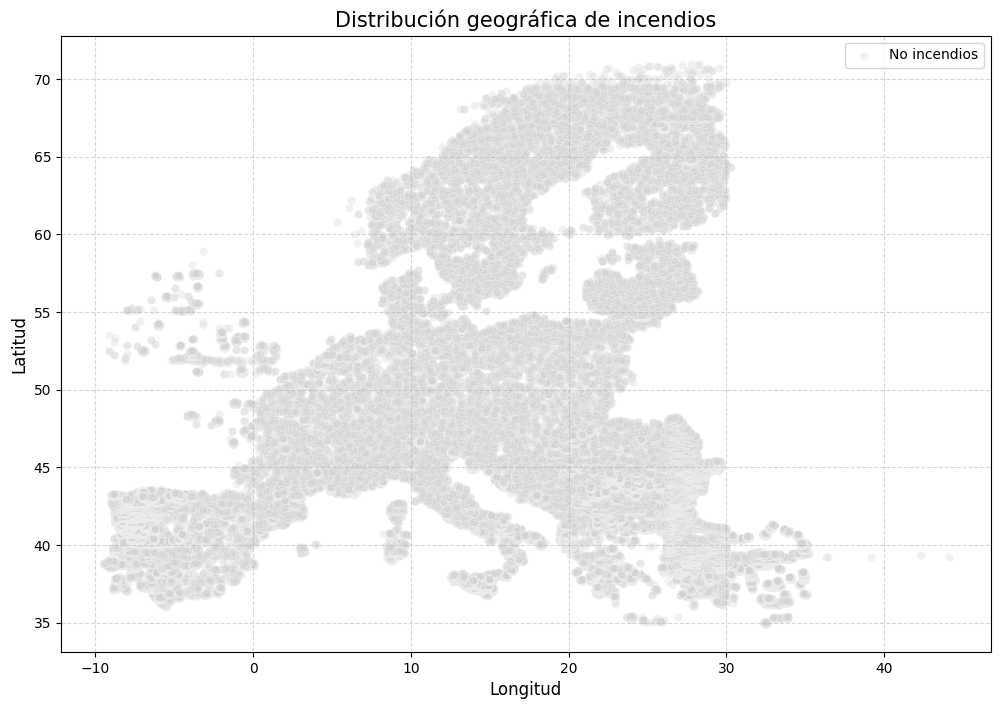

In [22]:
df_africa = filtros_no_sinteticos.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Norte_Africa.parquet", df, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_africa, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Norte de África')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_Norte_Africa.parquet', 4177))

Observamos si se han creado bien:

Dataframe importado correctamente


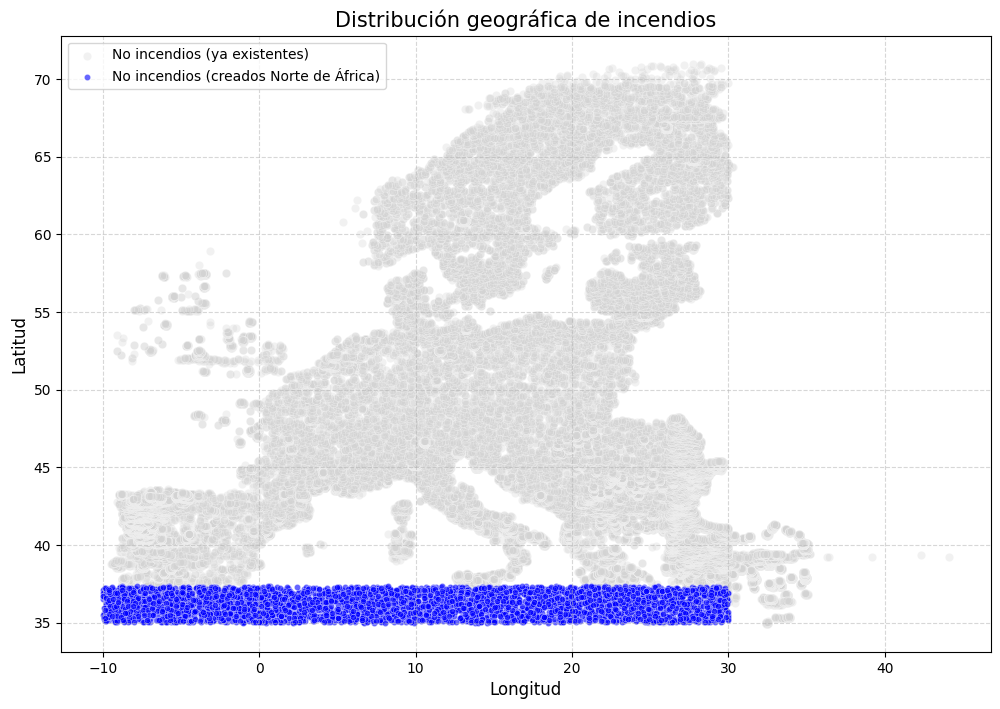

In [13]:
df_creados_africa = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/norte_africa.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_africa, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Norte de África)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**3.Crear puntos de no incendio en Bielorrusia:**

Evaluamos los incendios que tenemos en Bielorrusia:

Geodataframe importado correctamente


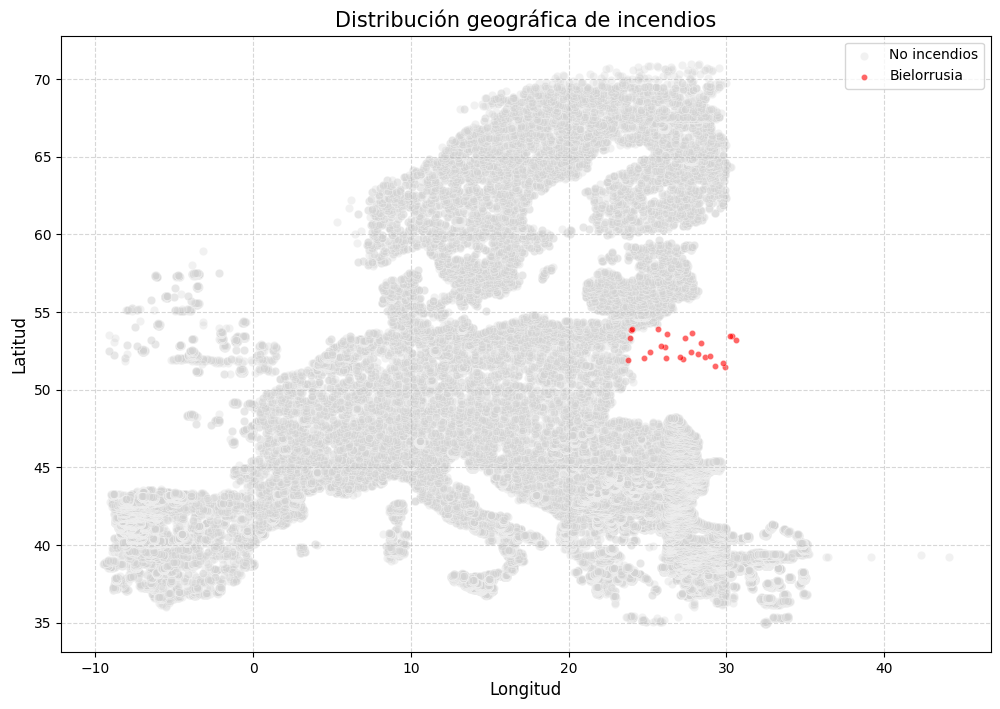

In [25]:
df_bielorrusia = filtros_no_sinteticos.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Belarus.parquet", df, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_bielorrusia, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Bielorrusia')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_Belarus.parquet', 762))

Observamos si se han creado bien:

Dataframe importado correctamente


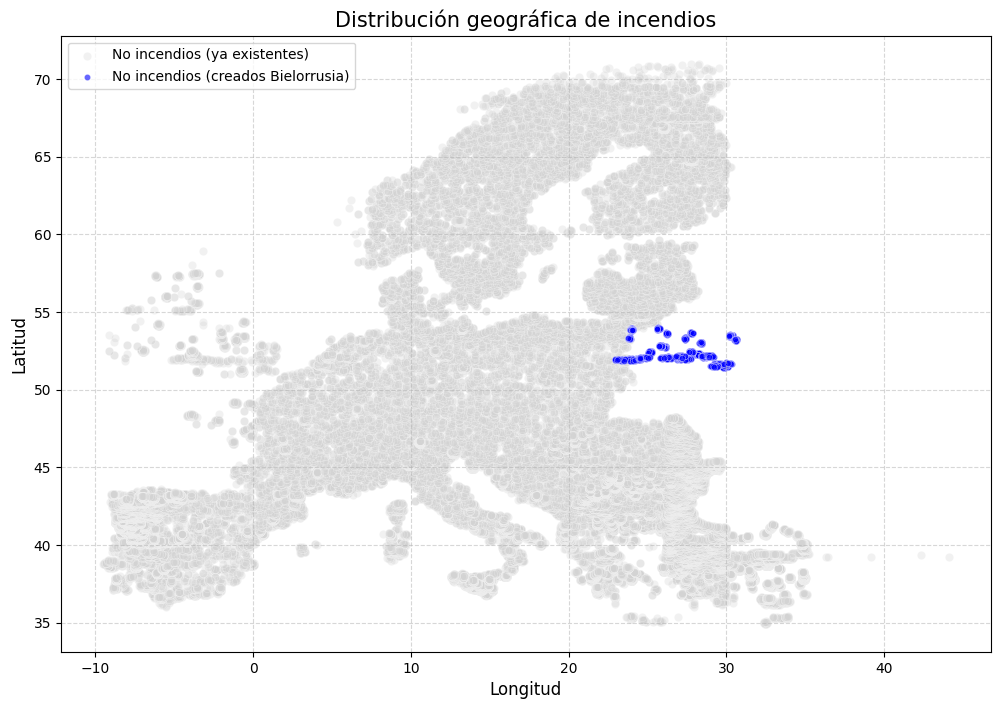

In [18]:
df_creados_bielorrusia = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/belarus.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_bielorrusia, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Bielorrusia)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**4.Crear puntos de no incendio en Rusia:**

Evaluamos los incendios que tenemos en Rusia:

Geodataframe importado correctamente


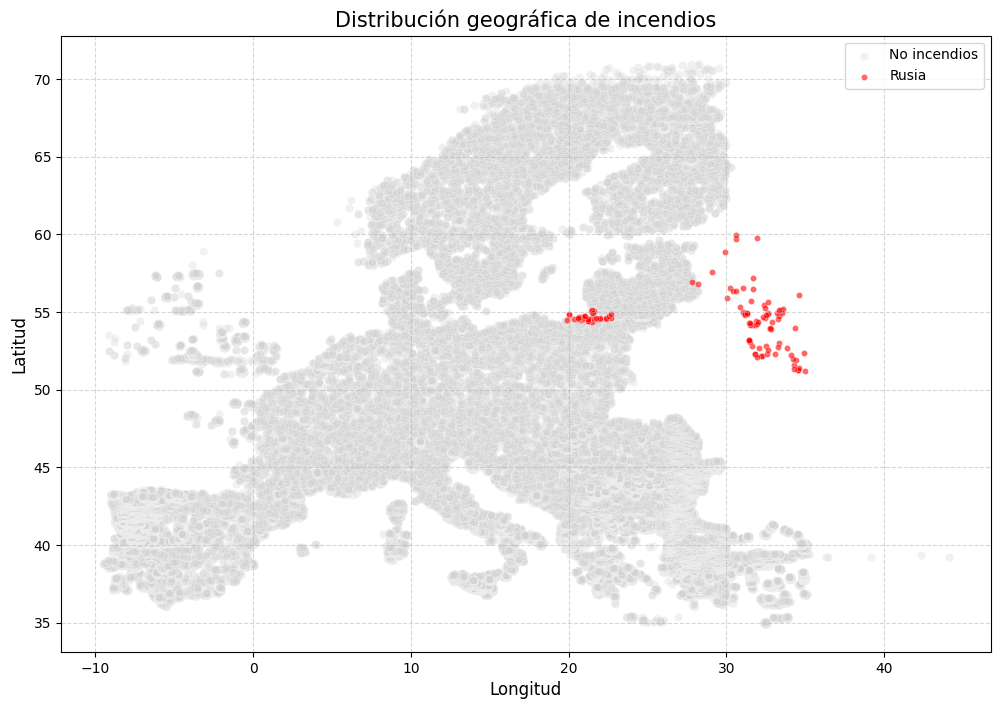

In [30]:
df_rusia = filtros_no_sinteticos.filtrar_zona_eliminar("grupo3/raw/Countries/mascara_Russian_Federation.parquet", df, cliente)

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_rusia, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Rusia')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
print(ps.crearSinteticosUnaZona(df, 'grupo3/raw/Countries/mascara_Russian_Federation.parquet', 7757))

Observamos si los hemos creado bien:

Dataframe importado correctamente


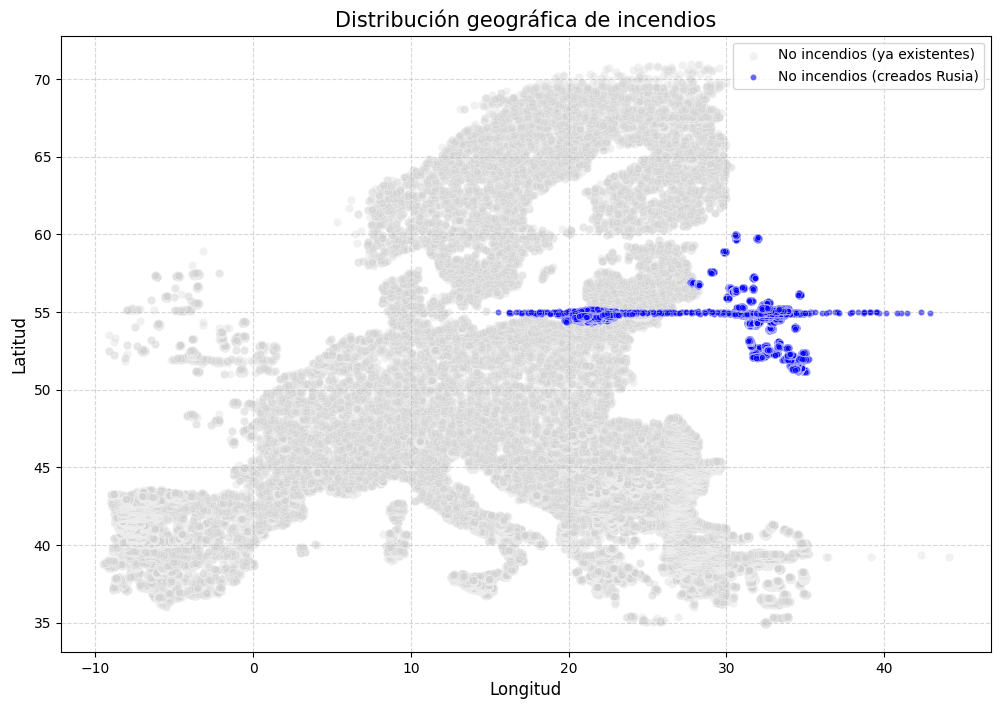

In [21]:
df_creados_rusia = mf.bajar_fichero(cliente, "grupo3/raw/No_incendios/Nuevas_Zonas/russia.parquet", "df")

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_final[df_final['final'] == 0], x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios (ya existentes)')

sns.scatterplot(data=df_creados_rusia, x='lon', y='lat', color='blue', alpha=0.6, s=20, label='No incendios (creados Rusia)')

plt.title('Distribución geográfica de incendios', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Contamos el número de puntos que hay actualmente por zona:**

In [3]:
print(ps.contarSinteticosPorArea(df))

Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
Geodataframe importado correctamente
G